# Google Speech Commands

Load Google Speech Commands v0.02 via HuggingFace, confirm 105,829 clips at 16 kHz,
verify the 10-command + unknown + silence class split. Report class distribution (some commands may have
slightly more examples). Listen to 10 samples per class to verify audio quality.

# Overview
This notebook loads and explores the Google Speech Commands v0.02 dataset for keyword spotting. The goal is to build a model that can detect 10 target keywords in the presence of background noise and unknown words.

## Dataset
**Google Speech Commands v0.02**: 105,829 one-second audio clips at 16kHz 
- 10 target keywords: yes, no, up, down, left, right, on, off, stop, go
- Unknown class: all other spoken words (~54,000 clips)
- Silence class: background noise recordings chunked into 1s clips (~400 clips)

**MUSAN**: Music, Speech, and Noise dataset used for noise injection during training
- Makes the model robust to real-world background noise
- Applied as augmentation — clips are still labeled as their original keyword

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torchcodec
import torchaudio
from torchaudio.datasets import SPEECHCOMMANDS
from IPython.display import Audio, display

from datasets import load_dataset

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# I think either of these paths should work, but the second one allows for an environment variable to be set for flexibility.
#DATA_ROOT = "./data"
DATA_ROOT = os.environ.get("DATA_ROOT", "./data")

os.makedirs(DATA_ROOT, exist_ok=True)

In [2]:
# Import train, val, test
train_set = SPEECHCOMMANDS(DATA_ROOT, download=True, subset="training")
val_set = SPEECHCOMMANDS(DATA_ROOT, download=True, subset="validation")
test_set = SPEECHCOMMANDS(DATA_ROOT, download=True, subset="testing")

print(f"Train: {len(train_set)} \nVal: {len(val_set)} \nTest: {len(test_set)}")
print(f"Total: {len(train_set) + len(val_set)+len(test_set)}")

100%|██████████| 2.26G/2.26G [00:46<00:00, 51.9MB/s]


Train: 84843 
Val: 9981 
Test: 11005
Total: 105829


In [6]:
# setup silence
silence_dir = os.path.join(DATA_ROOT, "SpeechCommands", "speech_commands_v0.02", "_background_noise_")

SAMPLE_RATE = 16000
CLIP_LENGTH = SAMPLE_RATE * 1

In [8]:
def create_silence_clips(silence_dir, clip_length=CLIP_LENGTH, sr=SAMPLE_RATE, overlap=0.5):
    hop_length = int(clip_length * (1 - overlap))
    silence_clips = []
 
    for fname in sorted(os.listdir(silence_dir)):
        if not fname.endswith(".wav"):
            continue
        filepath = os.path.join(silence_dir, fname)
        waveform, file_sr = torchaudio.load(filepath)
 
        if file_sr != sr:
            resampler = torchaudio.transforms.Resample(file_sr, sr)
            waveform = resampler(waveform)
 
        file_name = fname.replace(".wav", "")
        num_samples = waveform.shape[1]
        num_clips = 0
 
        start = 0
        while start + clip_length <= num_samples:
            clip = waveform[:, start : start + clip_length]
            silence_clips.append((clip, sr, "silence", file_name, num_clips))
            num_clips += 1
            start += hop_length
 
        print(f"{fname}: {num_clips} clips from {num_samples / sr:.1f}s of audio "
              f"(hop={hop_length / sr:.2f}s, overlap={overlap:.0%})")
 
    print(f"\nTotal silence clips: {len(silence_clips)}")
    print(f"Hop length: {hop_length} samples ({hop_length / sr:.2f}s)")
    return silence_clips

print('Silence class split:')

silence_clips = create_silence_clips(silence_dir)

for i in random.sample(range(len(silence_clips)), 5):
    waveform, sample_rate, label, speaker_id, utterance_number = silence_clips[i]
    print(f"Label: {label} | File Name: {speaker_id}")
    display(Audio(waveform.numpy(), rate=sample_rate))

Silence class split:
doing_the_dishes.wav: 189 clips from 95.2s of audio (hop=0.50s, overlap=50%)
dude_miaowing.wav: 122 clips from 61.8s of audio (hop=0.50s, overlap=50%)
exercise_bike.wav: 121 clips from 61.3s of audio (hop=0.50s, overlap=50%)
pink_noise.wav: 119 clips from 60.0s of audio (hop=0.50s, overlap=50%)
running_tap.wav: 121 clips from 61.2s of audio (hop=0.50s, overlap=50%)
white_noise.wav: 119 clips from 60.0s of audio (hop=0.50s, overlap=50%)

Total silence clips: 791
Hop length: 8000 samples (0.50s)
Label: silence | File Name: pink_noise


Label: silence | File Name: doing_the_dishes


Label: silence | File Name: doing_the_dishes


Label: silence | File Name: doing_the_dishes


Label: silence | File Name: dude_miaowing


##### Inspecting first example tuple structure

In [9]:
waveform, sample_rate, label, speaker_id, utterance_number = train_set[0]

print(f"Waveform shape: {waveform.shape}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Label: '{label}'")
print(f"Speaker ID: '{speaker_id}'")
print(f"Utterance Number: {utterance_number}")
print(f"Duration: {waveform.shape[1] / sample_rate:.3f}s")


Waveform shape: torch.Size([1, 16000])
Sample rate: 16000 Hz
Label: 'backward'
Speaker ID: '0165e0e8'
Utterance Number: 0
Duration: 1.000s


All samples verified at 16000 Hz

In [10]:
sr_df = pd.DataFrame(
    [train_set[i][1] for i in range(min(500, len(train_set)))],
    columns=["sample_rate"]
)

assert sr_df["sample_rate"].nunique() == 1, "Not all sample rates are equal!"
print(f"All samples verified at {sr_df['sample_rate'].iloc[0]} Hz")

All samples verified at 16000 Hz


##### Check Labels (Pre-Unknown)

In [12]:
labels_df = pd.DataFrame([train_set[i][2] for i in range(len(train_set))], columns=["label"])

unique_labels = set(labels_df["label"])

print(sorted(unique_labels))

['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [13]:
# pre-transform value counts (sampled)
value_counts = pd.DataFrame(labels_df.value_counts()).reset_index()
value_counts.head(10)

,label,count
0,zero,3250
1,five,3240
2,yes,3228
3,seven,3205
4,nine,3170
5,one,3140
6,down,3134
7,no,3130
8,two,3111
9,stop,3111


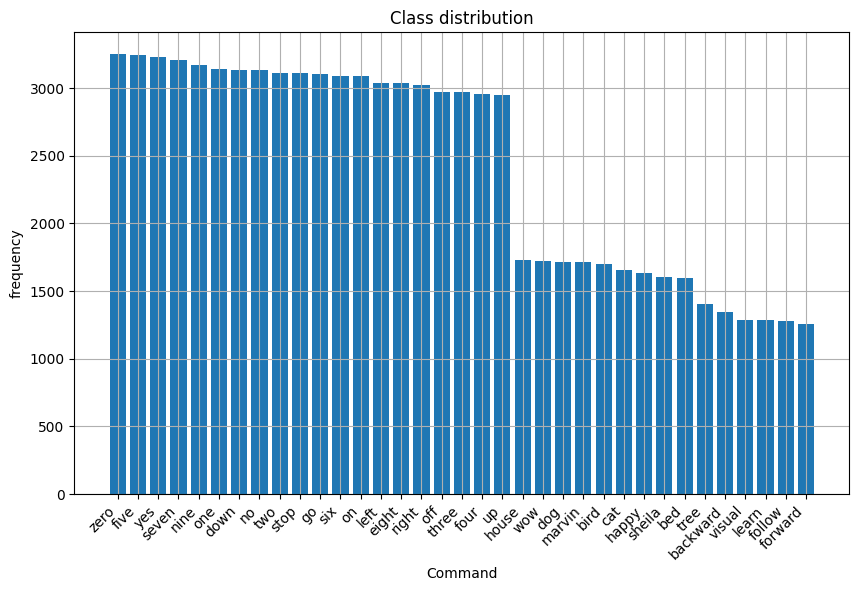

In [14]:
# pre-transform class distribution
fig, ax = plt.subplots(figsize = (10,6))
ax.bar(value_counts['label'], value_counts['count'])
ax.set_xlabel("Command")
ax.set_ylabel('frequency')
plt.xticks(rotation=45, ha='right')
ax.set_title("Class distribution")
ax.grid()
plt.show()

##### Transform target and unknown classes

In [18]:
from torch.utils.data import Dataset, ConcatDataset
class SilenceDataset(Dataset):
    def __init__(self, clips):
        self.clips = clips

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        return self.clips[idx]

silence_dataset = SilenceDataset(silence_clips)
train_set_full = ConcatDataset([train_set, silence_dataset])

In [19]:
target_labels = {"yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"}

def relabel(label):
    if label in target_labels or label == "silence":
        return label
    return "unknown"

relabeled = [relabel(train_set_full[i][2]) for i in range(len(train_set_full))]
relabel_df = pd.DataFrame(relabeled, columns=["label"])
relabeled_value_counts = pd.DataFrame(relabel_df.value_counts()).reset_index()

In [20]:
relabeled_value_counts.head(20)

,label,count
0,unknown,54074
1,yes,3228
2,down,3134
3,no,3130
4,stop,3111
5,go,3106
6,on,3086
7,left,3037
8,right,3019
9,off,2970


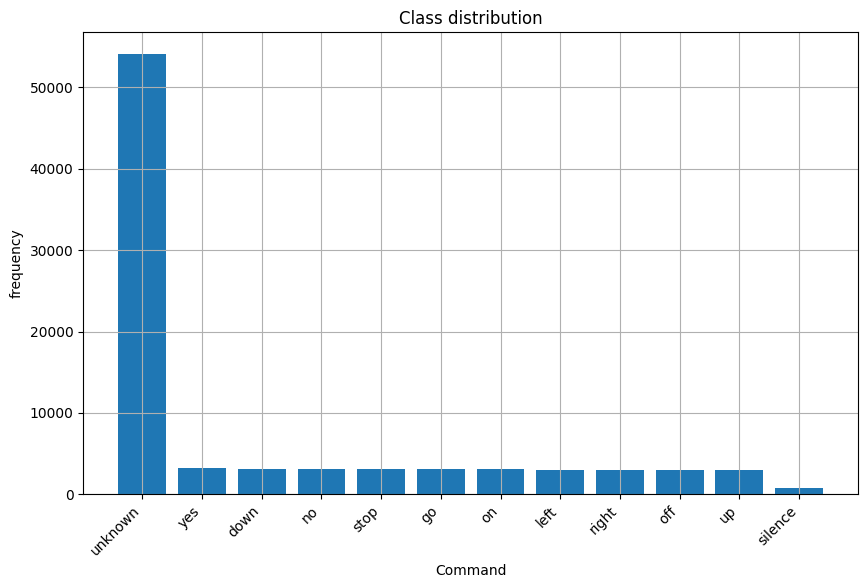

In [21]:
# post-transform class distribution
fig, ax = plt.subplots(figsize = (10,6))
ax.bar(relabeled_value_counts['label'], relabeled_value_counts['count'])
ax.set_xlabel("Command")
ax.set_ylabel('frequency')
plt.xticks(rotation=45, ha='right')
ax.set_title("Class distribution")
ax.grid()
plt.show()

In [22]:
for i in random.sample(range(len(train_set)), 5):
    waveform, sample_rate, label, speaker_id, utterance_number = train_set[i]
    print(f"Label: {label} | Speaker: {speaker_id} | Utterance: {utterance_number}")
    display(Audio(waveform.numpy(), rate=sample_rate))

Label: learn | Speaker: e9323bd9 | Utterance: 0


Label: three | Speaker: 71bf8f48 | Utterance: 1


Label: yes | Speaker: 28ed6bc9 | Utterance: 0


Label: bird | Speaker: 5588c7e6 | Utterance: 0


Label: up | Speaker: 620ff0fa | Utterance: 0


# MUSAN Dataset

Load the MUSAN data via Hugging Face. Verfiy the noise samples are at 16kHz, aligns with the Google Speech Commands dataset's sample rate.

In [23]:
# Load MUSAN dataset
ds = load_dataset("FluidInference/musan")

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/774 [00:00<?, ?it/s]

noise/free-sound/noise-free-sound-0001.w(…):   0%|          | 0.00/1.30M [00:00<?, ?B/s]

noise/free-sound/noise-free-sound-0000.w(…):   0%|          | 0.00/565k [00:00<?, ?B/s]

...

noise/sound-bible/noise-sound-bible-0074(…):   0%|          | 0.00/66.1k [00:00<?, ?B/s]

noise/sound-bible/noise-sound-bible-0076(…):   0%|          | 0.00/1.85M [00:00<?, ?B/s]

noise/sound-bible/noise-sound-bible-0077(…):   0%|          | 0.00/165k [00:00<?, ?B/s]

noise/sound-bible/noise-sound-bible-0075(…):   0%|          | 0.00/1.05M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/774 [00:00<?, ? examples/s]

In [24]:
print(f"Splits available: {list(ds.keys())}")
print(f"Train: {len(ds['train'])}")
print(f"\nFeatures: {ds['train'].features}")

Splits available: ['train']
Train: 774

Features: {'audio': Audio(sampling_rate=None, decode=True, num_channels=None, stream_index=None), 'label': ClassLabel(names=['free-sound', 'sound-bible'])}


In [25]:
# Inspect a single sample
sample = ds["train"][0]

print(f"Keys: {list(sample.keys())}")

# Accessing the label value and its corresponding name
label_value = sample['label']
label_name = ds["train"].features["label"].names[label_value]

print(f"Label Value: {label_value}")
print(f"Label Name: '{label_name}'")
print(f"Sample rate: {sample['audio']['sampling_rate']} Hz")

waveform = torch.tensor(sample["audio"]["array"]).unsqueeze(0).float()
sample_rate = sample["audio"]["sampling_rate"]

print(f"Waveform shape: {waveform.shape}")
print(f"Duration: {waveform.shape[1] / sample_rate:.3f}s")

Keys: ['audio', 'label']
Label Value: 0
Label Name: 'free-sound'
Sample rate: 16000 Hz
Waveform shape: torch.Size([1, 282540])
Duration: 17.659s


In [26]:
# Sample rate distribution
sr_df = pd.DataFrame(
    [ds["train"][i]["audio"]["sampling_rate"] for i in range(min(200, len(ds["train"])))],
    columns=["sample_rate"]
)

assert sr_df["sample_rate"].nunique() == 1, "Not all MUSAN sample rates are equal!"
print(f"All MUSAN samples verified at {sr_df['sample_rate'].iloc[0]} Hz")

All MUSAN samples verified at 16000 Hz


In [27]:
# Category distribution
category_df = pd.DataFrame(
    [ds["train"].features["label"].names[ds["train"][i]["label"]] for i in range(len(ds["train"]))],
    columns=["category"]
)

unique_categories = sorted(set(category_df["category"]))
print(f"Unique categories: {unique_categories}")

value_counts = category_df["category"].value_counts().reset_index()
value_counts.columns = ["category", "count"]

print(value_counts)

Unique categories: ['free-sound', 'sound-bible']
      category  count
0   free-sound    728
1  sound-bible     46


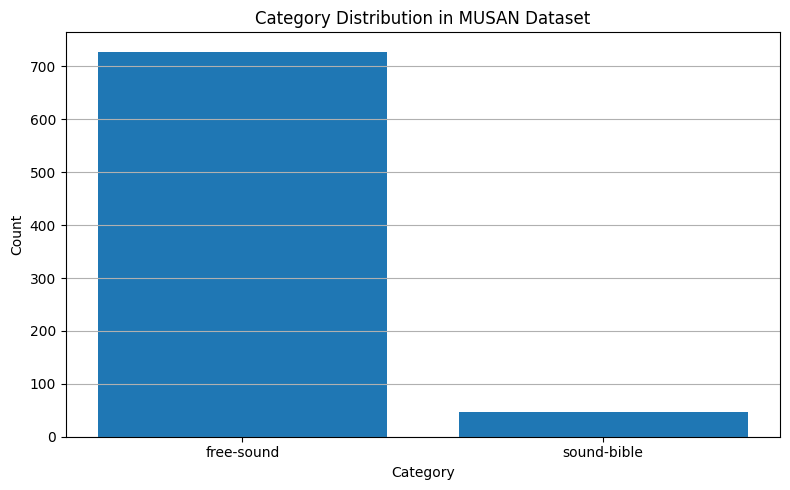

In [28]:
# Category distribution bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(value_counts["category"], value_counts["count"])
ax.set_xlabel("Category")
ax.set_ylabel("Count")
ax.set_title("Category Distribution in MUSAN Dataset")
ax.grid(axis='y')
plt.tight_layout()
plt.show()

In [29]:
# Listen to random samples per category
for cat in unique_categories:
    cat_indices = [i for i in range(len(ds["train"]))
                   if ds["train"].features["label"].names[ds["train"][i]["label"]] == cat]
    sampled = random.sample(cat_indices, min(4, len(cat_indices)))

    print(f"\n{cat.upper()} samples")
    for i in sampled:
        item = ds["train"][i]
        waveform = np.array(item["audio"]["array"])
        sr = item["audio"]["sampling_rate"]
        label = ds["train"].features["label"].names[item["label"]]
        print(f"Category: {label} | Duration: {len(waveform)/sr:.2f}s | Sample rate: {sr} Hz")
        display(Audio(waveform, rate=sr))


FREE-SOUND samples
Category: free-sound | Duration: 41.59s | Sample rate: 16000 Hz


Category: free-sound | Duration: 12.51s | Sample rate: 16000 Hz


Category: free-sound | Duration: 14.94s | Sample rate: 16000 Hz


Category: free-sound | Duration: 14.68s | Sample rate: 16000 Hz



SOUND-BIBLE samples
Category: sound-bible | Duration: 62.64s | Sample rate: 16000 Hz


Category: sound-bible | Duration: 7.03s | Sample rate: 16000 Hz


Category: sound-bible | Duration: 1.33s | Sample rate: 16000 Hz


Category: sound-bible | Duration: 27.74s | Sample rate: 16000 Hz


## Phase 1 - MUSAN Injection

In [30]:
TARGET_SR = 16000
TARGET_LEN = 16000

def fit_noise_to_length(noise_waveform, target_len=TARGET_LEN):
    cur_len = noise_waveform.shape[1]

    if cur_len > target_len:
        start = random.randint(0, cur_len - target_len)
        return noise_waveform[:, start:start + target_len]

    if cur_len < target_len:
        repeats = (target_len // cur_len) + 1
        noise_waveform = noise_waveform.repeat(1, repeats)

    return noise_waveform[:, :target_len]

def compute_rms(waveform, eps=1e-8):
    return torch.sqrt(torch.mean(waveform ** 2) + eps)

def mix_at_snr(speech, noise, snr_db):
    speech_rms = compute_rms(speech)
    noise_rms = compute_rms(noise)

    desired_noise_rms = speech_rms / (10 ** (snr_db / 20))
    scale = desired_noise_rms / (noise_rms + 1e-8)

    noisy = speech + scale * noise
    return torch.clamp(noisy, -1.0, 1.0)

def inject_musan_noise(speech_waveform, musan_item, snr_db):
    noise = torch.tensor(musan_item["audio"]["array"]).float().unsqueeze(0)

    if musan_item["audio"]["sampling_rate"] != TARGET_SR:
        resampler = torchaudio.transforms.Resample(
            musan_item["audio"]["sampling_rate"], TARGET_SR
        )
        noise = resampler(noise)

    noise = fit_noise_to_length(noise, TARGET_LEN)
    speech_waveform = fit_noise_to_length(speech_waveform, TARGET_LEN)

    return mix_at_snr(speech_waveform, noise, snr_db)

### Test

In [31]:
idx = 0
waveform, sr, label, speaker_id, utt = train_set[idx]

musan_item = ds["train"][10]
noisy = inject_musan_noise(waveform, musan_item, snr_db=10)

print(label)
display(Audio(waveform.numpy(), rate=sr))
display(Audio(noisy.numpy(), rate=sr))


backward


In [32]:
test_words = ["yes", "no"]
# more words can be added, but for demo purposes we'll just do 2 to keep the output manageable
# test_words = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"] --- IGNORE ---

snr_levels = [20, 10, 0, -5]

for word in test_words:
    print("\n==============================")
    print("Keyword:", word)

    # find indices of this keyword
    indices = [i for i in range(len(train_set)) if train_set[i][2] == word]

    # sample a few examples
    sampled = random.sample(indices, 2)

    for idx in sampled:
        waveform, sr, label, speaker_id, utt = train_set[idx]
        musan_item = ds["train"][random.randint(0, len(ds["train"]) - 1)]

        print(f"\nSpeaker: {speaker_id}")

        display(Audio(waveform.numpy(), rate=sr))

        for snr in snr_levels:
            noisy = inject_musan_noise(waveform, musan_item, snr_db=snr)
            print(f"SNR = {snr} dB")
            display(Audio(noisy.numpy(), rate=sr))


Keyword: yes

Speaker: 019fa366


SNR = 20 dB


SNR = 10 dB


SNR = 0 dB


SNR = -5 dB


...


Speaker: 7846fd85


SNR = 20 dB


SNR = 10 dB


SNR = 0 dB


SNR = -5 dB


In [34]:
import torch
import torchaudio.transforms as T
from torch.utils.data import DataLoader
import random
import torch.nn.functional as F

TARGET_KEYWORDS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
label_to_id = {word: idx for idx, word in enumerate(TARGET_KEYWORDS)}
label_to_id['_unknown_'] = 10
label_to_id['_silence_'] = 11

def encode_label(label):
    if label == 'silence' or label == '_silence_':
        return label_to_id['_silence_']
    elif label in TARGET_KEYWORDS:
        return label_to_id[label]
    else:
        return label_to_id['_unknown_']

mel_transform = T.MelSpectrogram(
    sample_rate=16000,
    n_fft=400,
    hop_length=160,
    n_mels=40
)

amplitude_to_db = T.AmplitudeToDB()

def collate_fn(batch, is_training=False):
    tensors = []
    targets = []
    
    for item in batch:
        waveform = item[0]
        label = item[2]
        '''
        if is_training and random.random() < 0.5: # 50% chance to add noise
            # Grab a random noise clip
            musan_item = ds["train"][random.randint(0, len(ds["train"]) - 1)]
            # Inject it at a random Signal-to-Noise Ratio (SNR)
            snr = random.choice([0, 5, 10, 15])
            waveform = inject_musan_noise(waveform, musan_item, snr_db=snr)
        '''
    
        if waveform.shape[1] > 16000:
            waveform = waveform[:, :16000]
        elif waveform.shape[1] < 16000:
            pad_amount = 16000 - waveform.shape[1]
            waveform = F.pad(waveform, (0, pad_amount))
            
        mel = mel_transform(waveform)
        mel_db = amplitude_to_db(mel)
        
        tensors.append(mel_db)
        targets.append(encode_label(label))
        
    tensors = torch.stack(tensors)
    targets = torch.tensor(targets)
    
    return tensors, targets

train_collate = lambda batch: collate_fn(batch, is_training=True)
eval_collate = lambda batch: collate_fn(batch, is_training=False)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_set_full, 
    batch_size=BATCH_SIZE, 
    shuffle=True,         
    collate_fn=train_collate, 
    num_workers=0         
)

val_loader = DataLoader(
    val_set, 
    batch_size=BATCH_SIZE, 
    shuffle=False,        
    collate_fn=eval_collate, 
    num_workers=0
)

test_loader = DataLoader(
    test_set, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=eval_collate, 
    num_workers=0
)

features, labels = next(iter(train_loader))
print(f"Batch Features Shape: {features.shape} -> [Batch Size, Channels, Mels, Time Frames]")
print(f"Batch Labels Shape: {labels.shape}")

Batch Features Shape: torch.Size([64, 1, 40, 101]) -> [Batch Size, Channels, Mels, Time Frames]
Batch Labels Shape: torch.Size([64])
